## Download ENTEx experiments and extract files

In [1]:
import importlib
import pandas as pd
from pathlib import Path
from collections import Counter

import brew_omics
importlib.reload(brew_omics)

# ONLY experiments are needed for ENTEx and others are obtained from ENCODE folder
init_experiments, init_experiments_path = brew_omics.fetch_encode_metadata(
    "data/entex/init_experiments.pkl",
    "https://www.encodeproject.org/report.tsv?type=Experiment&status=released&internal_tags=ENTEx&limit=all",
    check_ids=['ID'], skip_rows=1, sep='\t', data_type='Experiment', overwrite=False)

# report_sam, report_sam_path = brew_omics.fetch_encode_metadata(
#     "data/entex/report_sam.pkl",
#     "https://www.encodeproject.org/report.tsv?type=Biosample&status=released&internal_tags=ENTEx&limit=all",
#     check_ids=['Accession'], skip_rows=1, sep='\t', data_type='Biosample', overwrite=False)

# metadata_file, metadata_file_path = brew_omics.fetch_encode_metadata(
#     "data/entex/metadata_file.pkl",
#     "https://www.encodeproject.org/metadata/?type=Experiment&status=released&internal_tags=ENTEx&limit=all",
#     check_ids=['File accession'], skip_rows=0, sep='\t', data_type='File', overwrite=False)

# Somehow this failed, probably internal_tags does not work for type=File
# report_file, report_file_path = brew_omics.fetch_encode_metadata(
#     "data/entex/report_file.pkl",
#     "https://www.encodeproject.org/report.tsv?type=File&status=released&internal_tags=ENTEx&limit=all",
#     check_ids=['ID', 'Dataset'],
#     skip_rows=1, sep='\t',
#     data_type='File')

Loaded cached ENCODE Experiment metadata with shape: (1586, 40)
    column 'ID': experiments = 1586


In [2]:
# 1) File-centric data frame for ENTex files with biosample information
encode_files_samples = pd.read_pickle("data/encode/init_files_samples.pkl")

encode_files_samples.set_index('Accession', inplace=True, drop=False)
encode_files_samples.index.name = 'Index'
encode_file_accs = set(encode_files_samples['Accession'].tolist())

# column "Files" in report_expt contains list of file ids, separated by commas
entex_file_accs = []
for file_list in init_experiments['Files'].dropna():
    entex_file_accs.extend([f.strip('/').split('/')[-1] for f in file_list.split(',')])

print(f"A total of file accessions found in experiments: {len(entex_file_accs)}")
print(entex_file_accs[:5])

files_not_found = [f for f in entex_file_accs if f not in encode_file_accs]
if len(files_not_found) == 0:
    print("All files in experiments are present in encode_files_samples.")
else:
    print(f"Missing files in encode_files_samples: {files_not_found}")

# Extract the rows in report_file_biosample corresponding to the file_accessions
init_files_samples = encode_files_samples.loc[entex_file_accs]
print(f"Extracted ENTex files_samples shape: {init_files_samples.shape}")

# Save the extracted report_file_biosample_entex
init_files_samples.to_pickle("data/entex/init_files_samples.pkl")
init_files_samples.to_csv("data/entex/init_files_samples.csv", index=False)
print("Saved extracted init_files_samples to data/entex/init_files_samples.pkl/csv")

final_files_samples = init_files_samples[init_files_samples['Biosample accession'].notna()]
print(f"final_files_samples shape: {final_files_samples.shape}")
final_files_samples.to_pickle("data/entex/final_files_samples.pkl")
final_files_samples.to_csv("data/entex/final_files_samples.csv", index=False)
print("Saved final_files_samples to data/entex/final_files_samples.pkl/csv")

# 2) Sample-centric data frame for final samples
init_samples_merged = pd.read_pickle("data/encode/init_samples_merged.pkl")
print(f"Loaded ENCODE biosample data with shape: {init_samples_merged.shape}")
init_samples_merged.set_index('Accession', inplace=True, drop=False)
init_samples_merged.index.name = 'Index'

final_samples_accs = final_files_samples['Biosample accession'].unique().tolist()
print(f"Number of unique biosample accessions in final_files_samples: {len(final_samples_accs)}")

# Get the list of biosample accessions from final_files_samples
final_samples = init_samples_merged[init_samples_merged['Accession'].isin(final_samples_accs)]
# final_samples.to_pickle("data/entex/final_samples.pkl")
final_samples.to_csv("data/entex/final_samples.csv", index=False)
print("Saved final filtered biosample data to data/entex/final_samples.pkl/csv")

A total of file accessions found in experiments: 37291
['ENCFF854PQD', 'ENCFF851TIV', 'ENCFF565HBG', 'ENCFF542ZZT', 'ENCFF064KQN']
All files in experiments are present in encode_files_samples.
Extracted ENTex files_samples shape: (37291, 89)
Saved extracted init_files_samples to data/entex/init_files_samples.pkl/csv
final_files_samples shape: (5462, 89)
Saved final_files_samples to data/entex/final_files_samples.pkl/csv
Loaded ENCODE biosample data with shape: (29934, 34)
Number of unique biosample accessions in final_files_samples: 669
Saved final filtered biosample data to data/entex/final_samples.pkl/csv


## Visualize final files/samples and download

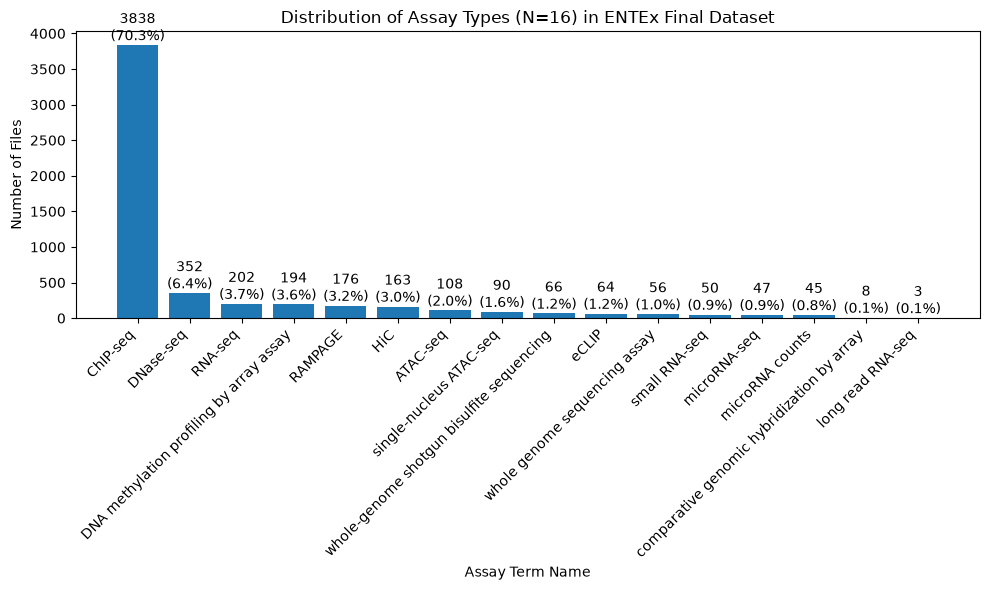

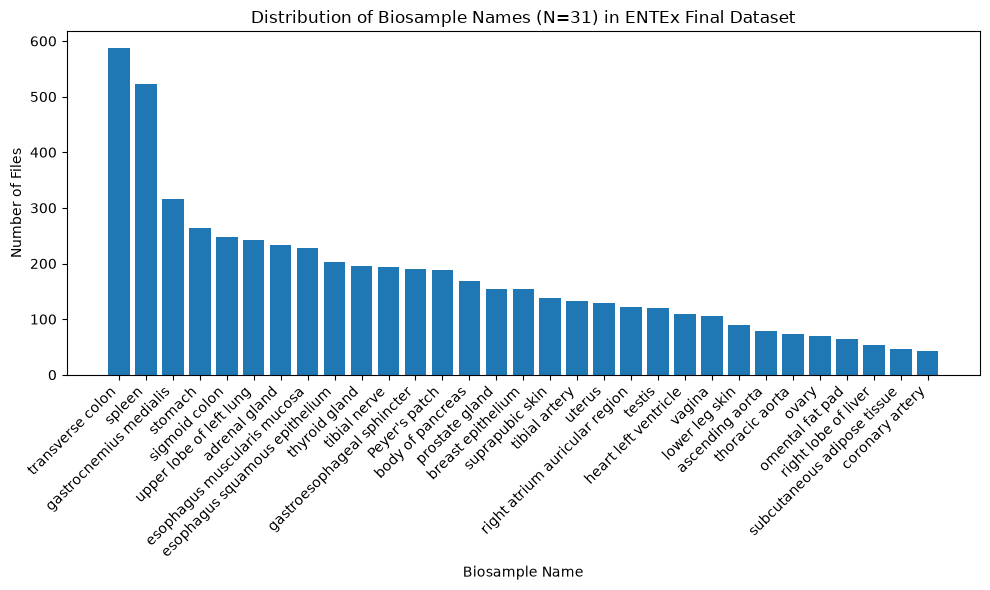

In [5]:
# import gwplot
# gwplot.ply_dfs_xy(final_files_samples, y='Assay term name', fmt='countstackedbar',
#     title='ENTEx final files samples by Organ and Assay term name',
#     plot_width=900, plot_height=600,
#     margin_r=300,
#     outfile="data/entex/plots/entex_final_files_samples_by_organ_assay_term_name.html")

# import glance_df
# gdf = glance_df.MyDataFrame(final_files_samples)
# gdf.plx_xys(x='Assay term name', fmt='pie',)

import matplotlib.pyplot as plt
import importlib
from src import visuals

importlib.reload(visuals)

visuals.plot_encode_assay_sample_distribution(final_files_samples, assay_col='Assay term name', sample_col='Biosample name',
    name='ENTEx Final', assay_label='Assay Term Name', sample_label='Biosample Name',
    plot_path="data/entex/plots/entex_final_files_samples_assay_term_name_distribution.png")


In [ ]:
import importlib
importlib.reload(brew_omics)
importlib.reload(brew_omics.gwio)

assay_col = 'Assay term name' # 'Assay title' has 'RNA-seq' as "total RNA-seq"
assay_file_types = {
    'RNA-seq': ['fastq',],
    'DNase-seq': ['fastq',],
    'ATAC-seq': ['fastq',],
}


groupby_col = 'Biosample accession'
groupby_col = 'Organ'
groupby_col = 'Biosample name'  # this gives the same tissue list as on ENTEx website table
download_dir = Path(f"data/entex/downloads_{groupby_col.lower().replace(' ', '_')}")

final_groups = final_files_samples.groupby(groupby_col)

# Get the files by dataset for the samples in final_files_samples, which will be used to find other files (e.g., bam, bigwig) from the same samples
init_files_samples.set_index('Accession', inplace=True, drop=False)
init_files_samples.index.name = 'Index'
files_by_dataset = init_files_samples.groupby('Dataset')

download_report = brew_omics.download_encode_files_by_groups(
    init_files_samples, # The master metata is needed to find other files (e.g., bam, bigwig) from the same samples
    assay_file_types,
    assay_col=assay_col,
    download_dir = download_dir,
    groupby_col = groupby_col, # not used if files_groups is provided, but needed to determine how to check same sample when downloading files from the same samples
    files_groups=final_groups, # the groups of files to download, which is determined by the final_files_samples
    files_by_dataset=files_by_dataset,
    check_same_sample=(groupby_col.lower() == 'biosample accession'),
    download_now=False,
)

print(f"Downloaded a total of {len(download_report)} files for selected biosamples and assay types.")
final_files_downloads = pd.merge(init_files_samples, download_report, on='Accession', how='inner', suffixes=('', '_download'))
final_files_downloads.to_pickle("data/entex/final_files_downloads.pkl")
final_files_downloads.to_csv("data/entex/final_files_downloads.csv", index=False)
print("Saved final downloaded files metadata to data/entex/final_files_downloads.pkl/csv")

Biosample name:  16%|█▌        | 5/31 [00:00<00:01, 16.28it/s]

Biosample name: Peyer's patch; saved metadata to data/entex/downloads_biosample_name/Peyer-s-patch.csv
    Assay: RNA-seq, Datasets: ['/experiments/ENCSR544SAU/', '/experiments/ENCSR257NIR/', '/experiments/ENCSR450BNZ/', '/experiments/ENCSR802HPM/']
    Dataset /experiments/ENCSR544SAU/ has 27 files.
    File accession: ENCFF891NXQ
        File data/entex/downloads_biosample_name/Peyer-s-patch/RNA-seq/ENCFF891NXQ.fastq.gz already exists, skipping download.
    File accession: ENCFF667RSP
        File data/entex/downloads_biosample_name/Peyer-s-patch/RNA-seq/ENCFF667RSP.fastq.gz already exists, skipping download.
    Dataset /experiments/ENCSR257NIR/ has 27 files.
    File accession: ENCFF896HPA
        File data/entex/downloads_biosample_name/Peyer-s-patch/RNA-seq/ENCFF896HPA.fastq.gz already exists, skipping download.
    File accession: ENCFF404WDI
        File data/entex/downloads_biosample_name/Peyer-s-patch/RNA-seq/ENCFF404WDI.fastq.gz already exists, skipping download.
    Datase

Biosample name:  39%|███▊      | 12/31 [00:00<00:00, 24.85it/s]

        File data/entex/downloads_biosample_name/coronary-artery/DNase-seq/ENCFF266RZG.fastq.gz already exists, skipping download.
    File accession: ENCFF399GZQ
        File data/entex/downloads_biosample_name/coronary-artery/DNase-seq/ENCFF399GZQ.fastq.gz already exists, skipping download.
    File accession: ENCFF324KZE
        File data/entex/downloads_biosample_name/coronary-artery/DNase-seq/ENCFF324KZE.fastq.gz already exists, skipping download.
    File accession: ENCFF174OBS
        File data/entex/downloads_biosample_name/coronary-artery/DNase-seq/ENCFF174OBS.fastq.gz already exists, skipping download.
    Dataset /experiments/ENCSR999TSD/ has 40 files.
    File accession: ENCFF763XNC
        File data/entex/downloads_biosample_name/coronary-artery/DNase-seq/ENCFF763XNC.fastq.gz already exists, skipping download.
    File accession: ENCFF644XQQ
        File data/entex/downloads_biosample_name/coronary-artery/DNase-seq/ENCFF644XQQ.fastq.gz already exists, skipping download.
  

Biosample name:  58%|█████▊    | 18/31 [00:00<00:00, 32.03it/s]

Biosample name: omental fat pad; saved metadata to data/entex/downloads_biosample_name/omental-fat-pad.csv
    Assay: RNA-seq, Datasets: ['/experiments/ENCSR645TCG/', '/experiments/ENCSR729CAZ/', '/experiments/ENCSR158KFO/', '/experiments/ENCSR080HPT/']
    Dataset /experiments/ENCSR645TCG/ has 27 files.
    File accession: ENCFF232YFL
        File data/entex/downloads_biosample_name/omental-fat-pad/RNA-seq/ENCFF232YFL.fastq.gz already exists, skipping download.
    File accession: ENCFF933AEB
        File data/entex/downloads_biosample_name/omental-fat-pad/RNA-seq/ENCFF933AEB.fastq.gz already exists, skipping download.
    Dataset /experiments/ENCSR729CAZ/ has 27 files.
    File accession: ENCFF745PTG
        File data/entex/downloads_biosample_name/omental-fat-pad/RNA-seq/ENCFF745PTG.fastq.gz already exists, skipping download.
    File accession: ENCFF824ZLA
        File data/entex/downloads_biosample_name/omental-fat-pad/RNA-seq/ENCFF824ZLA.fastq.gz already exists, skipping download

Biosample name:  87%|████████▋ | 27/31 [00:00<00:00, 33.97it/s]

    File accession: ENCFF346CDZ
    Dataset /experiments/ENCSR337UIU/ has 14 files.
    File accession: ENCFF326XJM
    File accession: ENCFF300KHX
Biosample name: subcutaneous adipose tissue; saved metadata to data/entex/downloads_biosample_name/subcutaneous-adipose-tissue.csv
    Assay: RNA-seq, Datasets: ['/experiments/ENCSR671WMH/', '/experiments/ENCSR150QJY/', '/experiments/ENCSR504NIU/', '/experiments/ENCSR708VVE/']
    Dataset /experiments/ENCSR671WMH/ has 27 files.
    File accession: ENCFF665BAC
        File data/entex/downloads_biosample_name/subcutaneous-adipose-tissue/RNA-seq/ENCFF665BAC.fastq.gz already exists, skipping download.
    File accession: ENCFF745QMZ
        File data/entex/downloads_biosample_name/subcutaneous-adipose-tissue/RNA-seq/ENCFF745QMZ.fastq.gz already exists, skipping download.
    Dataset /experiments/ENCSR150QJY/ has 27 files.
    File accession: ENCFF364IAX
        File data/entex/downloads_biosample_name/subcutaneous-adipose-tissue/RNA-seq/ENCFF36

Biosample name: 100%|██████████| 31/31 [00:01<00:00, 28.14it/s]


Biosample name: transverse colon; saved metadata to data/entex/downloads_biosample_name/transverse-colon.csv
    Assay: RNA-seq, Datasets: ['/experiments/ENCSR800WIY/', '/experiments/ENCSR653ZJF/', '/experiments/ENCSR403SZN/', '/experiments/ENCSR630VJN/']
    Dataset /experiments/ENCSR800WIY/ has 27 files.
    File accession: ENCFF069KBE
        File data/entex/downloads_biosample_name/transverse-colon/RNA-seq/ENCFF069KBE.fastq.gz already exists, skipping download.
    File accession: ENCFF122HNW
        File data/entex/downloads_biosample_name/transverse-colon/RNA-seq/ENCFF122HNW.fastq.gz already exists, skipping download.
    Dataset /experiments/ENCSR653ZJF/ has 27 files.
    File accession: ENCFF411UIT
        File data/entex/downloads_biosample_name/transverse-colon/RNA-seq/ENCFF411UIT.fastq.gz already exists, skipping download.
    File accession: ENCFF992NAN
        File data/entex/downloads_biosample_name/transverse-colon/RNA-seq/ENCFF992NAN.fastq.gz already exists, skipping do

## Prepare inputs to nextflow nf-core/rnaseq pipeline

In [ ]:
# Read and check data in final_files_downloads.pkl

if 'final_files_downloads' not in locals():
    final_files_downloads = pd.read_pickle("data/entex/final_files_downloads.pkl")
if 'Biosample accession_x' in final_files_downloads.columns:
    final_files_downloads.rename(columns={'Biosample accession_x': 'Biosample accession'}, inplace=True)

# for every column in final_files_downloads, check for empty/NaN values
for col in final_files_downloads.columns:
    num_missing = final_files_downloads[col].isna().sum()
    if num_missing > 0 and num_missing < len(final_files_downloads):
        print(f"Column '{col}' has {num_missing} missing/NaN values.")
    # check for empty strings
    num_empty = (final_files_downloads[col] == '').sum()
    if num_empty > 0 and num_empty < len(final_files_downloads):
        print(f"Column '{col}' has {num_empty} empty string values.")

# check if two columns (biosample term name and biosample name) are the same
if 'Biosample term name' in final_files_downloads.columns and 'Biosample name' in final_files_downloads.columns:
    biosample_term_names = final_files_downloads['Biosample term name'].tolist()
    sample_names = final_files_downloads['Biosample name'].tolist()
    all_same = all([a == b for a, b in zip(biosample_term_names, sample_names)])
    if all_same:
        print("Columns 'Biosample term name' and 'Biosample name' are identical.")
    else:
        print("Columns 'Biosample term name' and 'Biosample name' differ.")

# The plan is to process each sample separately
groupby_col = ['Dataset', 'Biosample accession', 'Assay term name', 'Library'] # or replace Library by "Technical replicates" (should be the same)
files_groupby_batch = final_files_downloads.groupby(groupby_col)
for group_keys, group_df in files_groupby_batch:
    dataset, sample_acc, assay_term, library = group_keys
    if dataset.endswith('BNH/'):
        print(f"Processing Dataset: {dataset}, Biosample: {sample_acc}, Assay: {assay_term}, Library: {library}, Number of files: {group_df.shape[0]}, Files: {group_df['Accession'].tolist()}")

Column 'dbxrefs' has 8 missing/NaN values.
Column 'replicate.library.dbxrefs' has 8 missing/NaN values.
Column 'Description' has 460 missing/NaN values.
Column 'External resources' has 4 missing/NaN values.
Columns 'Biosample term name' and 'Biosample name' are identical.
Processing Dataset: /experiments/ENCSR853BNH/, Biosample: ENCBS543SZC, Assay: RNA-seq, Library: ENCLB011CNK, Number of files: 2, Files: ['ENCFF387IXO', 'ENCFF307UCJ']
Processing Dataset: /experiments/ENCSR853BNH/, Biosample: ENCBS543SZC, Assay: RNA-seq, Library: ENCLB236RKR, Number of files: 2, Files: ['ENCFF004CNM', 'ENCFF086LCO']


In [ ]:
import brew_omics
import importlib
importlib.reload(brew_omics)

# sample_classifications = init_files_samples['Biosample classification'].value_counts().to_dict()
# print(f"Unique biosample classifications: {sample_classifications}")

# load the final_files_downloads if not already in memory
if 'final_files_downloads' not in locals():
    final_files_downloads = pd.read_pickle("data/entex/final_files_downloads.pkl")

assay_col = 'Assay term name' # 'Assay title' has 'RNA-seq' as "total RNA-seq"
assay_file_types = {
    'RNA-seq': ['fastq',],
    'DNase-seq': ['fastq',],
    'ATAC-seq': ['fastq',],
}

groupby_col = 'Biosample accession'
groupby_col = 'Organ'
groupby_col = 'Biosample name'  # this gives the same tissue list as on ENTEx website table

download_dir = Path(f"data/entex/downloads_{groupby_col.lower().replace(' ', '_')}")
# download_dir = Path(f"data/entex/downloads_sample_name")
brew_omics.prepare_nextflow_inputs_for_encode(
    final_files_downloads,
    assay_file_types,
    assay_col=assay_col,
    groupby_col=groupby_col,
    download_dir=download_dir,
)

Number of unique Biosample name: 31, e.g., ["Peyer's patch", 'adrenal gland', 'ascending aorta', 'body of pancreas', 'breast epithelium']
Processing sample type: Peyer's patch with 26 files, 3 assay types
  Assay type: RNA-seq, file type: fastq, # of files: 8, # of libraries: 4
    Saved file list to: data/entex/downloads_biosample_name/Peyer-s-patch_RNA-seq_fastq_nextflow.csv
  Assay type: DNase-seq, file type: fastq, # of files: 16, # of libraries: 4
    Saved file list for replicate 36 to: data/entex/downloads_biosample_name/Peyer-s-patch_DNase-seq_fastq_nextflow_readlen-36.csv
    Saved file list for replicate 76 to: data/entex/downloads_biosample_name/Peyer-s-patch_DNase-seq_fastq_nextflow_readlen-76.csv
  Assay type: ATAC-seq, file type: fastq, # of files: 2, # of libraries: 1
    Saved file list for replicate 100 to: data/entex/downloads_biosample_name/Peyer-s-patch_ATAC-seq_fastq_nextflow_readlen-100.csv
Processing sample type: adrenal gland with 44 files, 3 assay types
  Assay

## Process SpliSER outputs
Do this after running nextflow and spliser on the data generated above

In [ ]:
import os
import pandas as pd
import numpy as np
import gffutils
import importlib
from pyfaidx import Fasta
from tqdm import tqdm

import omics_utils
importlib.reload(omics_utils)

gencode_gtf_path = "data/spliser_refdata/gencode.v49.primary_assembly.annotation.gtf"
gencode_gtf_db_path = gencode_gtf_path + ".db"

if not os.path.exists(gencode_gtf_db_path):
    omics_utils.gffutils_create_gencode_db(gencode_gtf_path, gencode_gtf_db_path)
else:
    print(f"GFFUtils database exists: {gencode_gtf_db_path}")
gtf_db = gffutils.FeatureDB(gencode_gtf_db_path, keep_order=True)


tissue_records = omics_utils.spliser_get_tissue_records(dataset_dir="data/entex/RNA-seq_dataset/", tsv_pattern="*.SpliSER.tsv")
resume = True
for i, tissue_record in enumerate(tissue_records):
    tissue_dir = tissue_record['dir']
    tissue_name = tissue_record['name']
    print(f'Tissue: {i+1}/{len(tissue_records)} - {tissue_name}')
    
    if resume and os.path.exists(tissue_record['combined_tsv_file']):
        print(f"Combined TSV file already exists for tissue {tissue_record['name']}, skipping combination.")
    else:
        tissue_combined_df = omics_utils.spliser_combine_tsv_files(
            tissue_record['spliser_files'], combined_tsv_file=tissue_record['combined_tsv_file'], resume=resume)
        if tissue_combined_df.empty:
            print(f"No data found for tissue {tissue_name}, skipping splice site collection.")
            continue

    if resume and os.path.exists(tissue_record['genesites_replicates_file']):
        print(f"genesites_replicates.pkl already exists for tissue {tissue_record['name']}, skipping collection.")
    else:
        tissue_combined_gf = tissue_combined_df.groupby('Gene')
        gene_ids = list(tissue_combined_gf.groups.keys())

        print(f"Collecting splice sites for {len(gene_ids)} genes in tissue type: {tissue_name}, Number of rows: {len(tissue_combined_df)}")
        omics_utils.check_gene_in_gtf_db(gene_ids, gtf_db)    

        replicate_names = tissue_combined_df['Sample'].unique().tolist()
        try:
            get_ipython()
            print("Running in Jupyter Notebook or Ipython")
            genesites_replicates_list = []
            for gene_id in tqdm(gene_ids):
                genesites = omics_utils.spliser_collect_gene_splice_sites(gene_id, gene_gf=tissue_combined_gf, replicate_names=replicate_names, debug=False)
                genesites_replicates_list.append(genesites)
        except NameError:
            import functools
            import misc
            genesites_replicates_list = misc.mpi_map(
                functools.partial(omics_utils.spliser_collect_gene_splice_sites, gene_gf=tissue_combined_gf, replicate_names=replicate_names), tqdm(gene_ids))

        genesites_replicates_df = pd.DataFrame(genesites_replicates_list)
        print(f"Saving genesites_replicates_list to {tissue_record['genesites_replicates_file']}")
        genesites_replicates_df.to_pickle(tissue_record['genesites_replicates_file'])

GFFUtils database exists: data/spliser_refdata/gencode.v49.primary_assembly.annotation.gtf.db
Found 29 dataset directories in data/entex/RNA-seq_dataset/.
Tissue directories: data/entex/RNA-seq_dataset/Peyer-s-patch to data/entex/RNA-seq_dataset/vagina
Tissue: 1/29 - Peyer-s-patch
Combined TSV file already exists for tissue Peyer-s-patch, skipping combination.
genesites_replicates.pkl already exists for tissue Peyer-s-patch, skipping collection.
Tissue: 2/29 - adrenal-gland
Combined TSV file already exists for tissue adrenal-gland, skipping combination.
genesites_replicates.pkl already exists for tissue adrenal-gland, skipping collection.
Tissue: 3/29 - ascending-aorta
Combined TSV file already exists for tissue ascending-aorta, skipping combination.
genesites_replicates.pkl already exists for tissue ascending-aorta, skipping collection.
Tissue: 4/29 - body-of-pancreas
Combined TSV file already exists for tissue body-of-pancreas, skipping combination.
genesites_replicates.pkl already e

KeyError: 'Gene'

In [5]:
importlib.reload(omics_utils)

genome_fasta_path = "data/spliser_refdata/GRCh38.primary_assembly.genome.fa"
gtf_db = gffutils.FeatureDB(gencode_gtf_db_path, keep_order=True)
genome_fasta = Fasta(genome_fasta_path)

for tissue_record in tissue_records[:1]:  # only process the first tissue for testing
    tissue_name = tissue_record['name']
    genesites_replicates_file = tissue_record['genesites_replicates_file']
    if not os.path.exists(genesites_replicates_file):
        print(f"genesites_replicates.pkl not found for tissue {tissue_record['name']}, skipping sequence retrieval.")
        continue

    print(f"Loading genesites_replicates_list from {genesites_replicates_file} for tissue {tissue_record['name']}.")
    genesites_replicates_df = pd.read_pickle(genesites_replicates_file)

    failed_genes, genesites_list, rnasites_list = [], [], []
    for idx, genesites_replicates in tqdm(genesites_replicates_df.iterrows(),
                                          total=genesites_replicates_df.shape[0], desc=f"Processing genes for tissue {tissue_name}"):
        genesites = omics_utils.retrieve_gene_meta_sequence(genesites_replicates, gtf_db, genome_fasta, debug=False)
        if genesites['gene_not_found'] or genesites['site_out_of_bounds']:
            failed_genes.append(genesites['gene_id'])
            continue

        genesites = omics_utils.spliser_average_samples_and_filter_sites(genesites, debug=False)
        genesites_list.append(genesites)

        rna_sites = omics_utils.spliser_convert_gene_to_rna_sites(genesites, debug=False)
        rnasites_list.append(rna_sites)

    print(f"Total genes with sequence retrieved: {len(genesites_list)}, Failed genes: {len(failed_genes)}")

    genesites_df = pd.DataFrame(genesites_list)
    genesites_file = os.path.join(tissue_record['dir'], f"spliser_genesites.pkl")
    genesites_df.to_pickle(genesites_file)
    print(f"Saved genesites_list to {genesites_file}")

    rnasites_df = pd.DataFrame(rnasites_list)
    rnasites_file = os.path.join(tissue_record['dir'], f"spliser_rnasites.pkl")
    rnasites_df.to_pickle(rnasites_file)
    print(f"Saved rnasites_list to {rnasites_file}")

Loading genesites_replicates_list from data/entex/RNA-seq_dataset/Peyer-s-patch/spliser_genesites_replicates.pkl for tissue Peyer-s-patch.


Processing genes for tissue Peyer-s-patch: 100%|██████████| 34242/34242 [03:21<00:00, 169.87it/s]


Total genes with sequence retrieved: 33856, Failed genes: 386
Saved genesites_list to data/entex/RNA-seq_dataset/Peyer-s-patch/spliser_genesites.pkl
Saved rnasites_list to data/entex/RNA-seq_dataset/Peyer-s-patch/spliser_rnasites.pkl


## (Obsolete) Download bam files directly

In [ ]:
# generate inputs to spliser from report_file_biosample and final_biosamples

download_dir = Path(f"data/entex/dataset")

assay_file_types = {
    'RNA-seq': ['bam',],
    'DNase-seq': ['bam',],
}
genome_assembly = 'GRCh38'
genome_annotation = 'V29' # not used currently

unique_classifications = init_files_samples['Biosample classification'].unique().tolist()
print(f"Unique biosample classifications: {unique_classifications}")
# assert all([cls.lower() == 'tissue' for cls in unique_classifications]), "Not all biosample classifications are 'tissue'"

files_groupby_tissue = init_files_samples.groupby('Biosample name')
print(f"Number of unique biosample term names: {len(files_groupby_tissue.groups)}, e.g., {list(files_groupby_tissue.groups.keys())[:5]}")

# For each sample type, find samples with a given assay type, and then get a list of bam files from all samples
for tissue_record, tissue_group in files_groupby_tissue:
    print(f"Processing sample type: {tissue_record} with {len(tissue_group)} files")
    for assay_type, file_exts in assay_file_types.items():
        # get the list of Biosample accessions for this tissue and assay type
        files_groupby_sample = tissue_group[tissue_group['Assay term name'].str.lower() == assay_type.lower()]['Biosample accession'].unique().tolist()

        for filetype in file_exts:
            print(f"  Assay type: {assay_type}, file type: {filetype}, number of biosamples: {len(files_groupby_sample)}")
            nextflow_inputs = []

            for sample_acc in files_groupby_sample:
                file_path = download_dir / sample_acc / assay_type 
                # find files of this type for this biosample under the path
                files_of_type = list(file_path.glob(f"*.{filetype}"))
                print(f"    Biosample accession: {sample_acc}, found {len(files_of_type)} files of type {filetype}")

                # Todo: check the file size and md5sum to ensure the file is correctly downloaded
                for f in files_of_type:
                    file_acc = f.stem
                    # check the Genome assembly of the file
                    file_metadata = init_files_samples.loc[file_acc]
                    file_genome_assembly = file_metadata['Genome assembly']
                    if file_genome_assembly != genome_assembly:
                        print(f"      Skipping file {file_acc} due to genome assembly mismatch: {file_genome_assembly} != {genome_assembly}")
                        continue
                    
                    print(f"      Adding file {file_acc} with genome assembly {file_genome_assembly}")
                    nextflow_inputs.append(str(f))
                
            if nextflow_inputs:
                output_file = download_dir / f"{tissue_record.replace(' ', '_')}_{assay_type}_{filetype}_files.txt"
                with open(output_file, 'w') as f:
                    for bam_file in nextflow_inputs:
                        f.write(f"{bam_file}\n")
                print(f"    Saved file list to: {output_file}")
            else:
                print(f"    No files found for tissue {tissue_record} and assay {assay_type}.")
    break

NameError: name 'init_files_samples' is not defined